In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr, ttest_ind

# Set the style for presentation-ready plots
sns.set_theme(style="whitegrid")

# Load our main data
main_data_path = r"data\data.xlsx"

df = pd.read_excel(main_data_path) 

print(f"Dataset loaded successfully! Total Participants: {len(df)}")

Dataset loaded successfully! Total Participants: 40


,age,score_phq,score_gad,score_stai_t,score_vrise
count,40.00,40.00,40.00,40.00,40.00
mean,22.78,6.02,5.00,45.00,31.88
std,1.80,4.63,4.31,14.63,3.98
min,19.00,0.00,0.00,21.00,17.00
25%,21.00,3.00,2.00,34.75,31.00
50%,23.00,4.50,4.00,42.00,33.00
75%,24.00,7.50,7.00,54.00,35.00
max,27.00,18.00,18.00,73.00,35.00


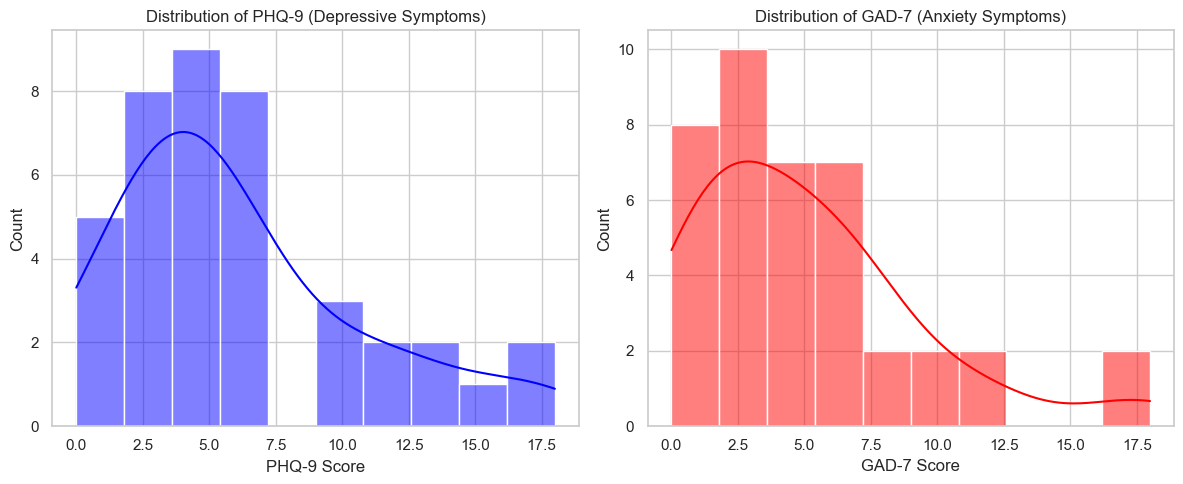

In [2]:
# 1. Generate Summary Table
clinical_cols = ['age', 'score_phq', 'score_gad', 'score_stai_t', 'score_vrise']
desc_stats = df[clinical_cols].describe().round(2)
display(desc_stats) # Take a screenshot of this for your presentation!

# 2. Plot Distributions of Depression and Anxiety
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['score_phq'], bins=10, kde=True, color='blue')
plt.title('Distribution of PHQ-9 (Depressive Symptoms)')
plt.xlabel('PHQ-9 Score')

plt.subplot(1, 2, 2)
sns.histplot(df['score_gad'], bins=10, kde=True, color='red')
plt.title('Distribution of GAD-7 (Anxiety Symptoms)')
plt.xlabel('GAD-7 Score')

plt.tight_layout()
plt.show() # Save this image for your presentation

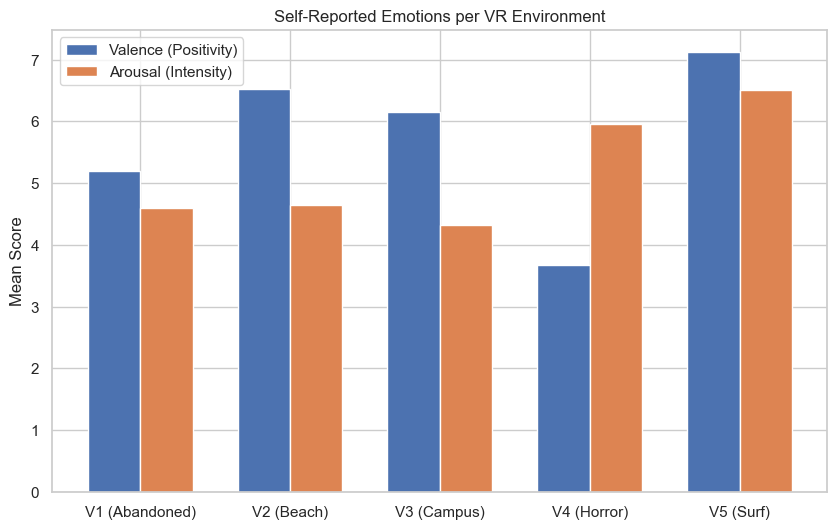

In [3]:
# Calculate mean valence and arousal across the 5 videos
videos = ['V1', 'V2', 'V3', 'V4', 'V5']
mean_valence = [df[f'valence_v{i}'].mean() for i in range(1, 6)]
mean_arousal = [df[f'arousal_v{i}'].mean() for i in range(1, 6)]

x = np.arange(len(videos))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, mean_valence, width, label='Valence (Positivity)')
plt.bar(x + width/2, mean_arousal, width, label='Arousal (Intensity)')

plt.xticks(x, ['V1 (Abandoned)', 'V2 (Beach)', 'V3 (Campus)', 'V4 (Horror)', 'V5 (Surf)'])
plt.ylabel('Mean Score')
plt.title('Self-Reported Emotions per VR Environment')
plt.legend()
plt.show() # Save this image for your presentation

In [6]:
# Define the base path for headtracking data
base_ht_path = r"data\headtracking-data"

# Function to read a single file and extract features
def get_tracking_features(filename, video_folder):
    # If the filename is empty, skip it
    if pd.isna(filename):
        return np.nan

    # Construct the full path: data\headtracking-data\v1\data_video1_...csv
    filepath = os.path.join(base_ht_path, video_folder, filename)

    # Check if the file actually exists
    if not os.path.exists(filepath):
        print(f"Missing file: {filepath}")
        return np.nan

    try:
        # Skip malformed trailing summary lines (e.g., "Circular Averages")
        track_df = pd.read_csv(filepath, on_bad_lines="skip")

        if "RotationSpeedTotal" not in track_df.columns:
            print(f"Missing RotationSpeedTotal column: {filepath}")
            return np.nan

        rotation_speed = pd.to_numeric(track_df["RotationSpeedTotal"], errors="coerce")
        avg_speed = rotation_speed.mean(skipna=True)
        return avg_speed
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return np.nan

# Apply the function to Video 1 (v1)
# Make sure your main dataset has a column named 'v1' containing the filenames
df['v1_avg_speed'] = df['v1'].apply(lambda x: get_tracking_features(x, 'v1'))

print("Headtracking data for Video 1 successfully extracted!")

Headtracking data for Video 1 successfully extracted!


Pearson Correlation Results:
r = -0.077, p-value = 0.636
Conclusion: No significant correlation found in this initial exploration.


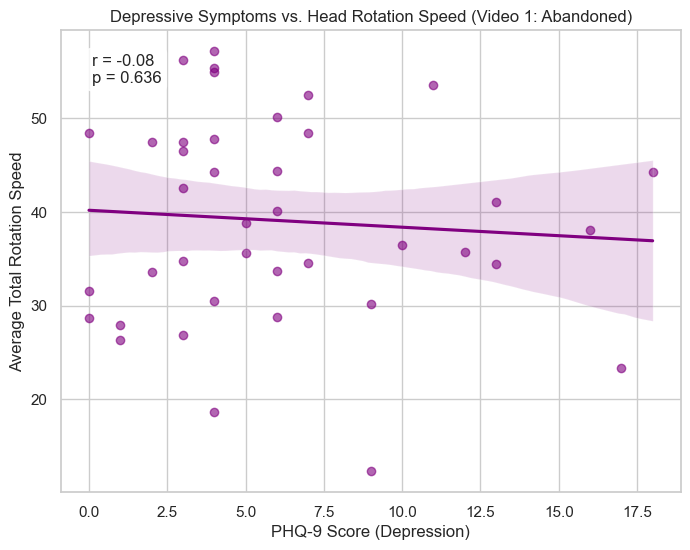

In [7]:
# Drop rows where we are missing PHQ scores or tracking data
test_df = df.dropna(subset=['score_phq', 'v1_avg_speed'])

# Run a Pearson Correlation
r, p_val = pearsonr(test_df['score_phq'], test_df['v1_avg_speed'])
print(f"Pearson Correlation Results:")
print(f"r = {r:.3f}, p-value = {p_val:.3f}")

if p_val < 0.05:
    print("Conclusion: Significant correlation found!")
else:
    print("Conclusion: No significant correlation found in this initial exploration.")

# Create the final scatter plot
plt.figure(figsize=(8, 6))
sns.regplot(data=test_df, x='score_phq', y='v1_avg_speed', color='purple', scatter_kws={'alpha':0.6})
plt.title('Depressive Symptoms vs. Head Rotation Speed (Video 1: Abandoned)')
plt.xlabel('PHQ-9 Score (Depression)')
plt.ylabel('Average Total Rotation Speed')

# Add the stats text to the plot
plt.text(0.05, 0.95, f'r = {r:.2f}\np = {p_val:.3f}', 
         transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show() # Save this image for your presentation